In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from collections import namedtuple

# van der Pol oscillator without external forcing

### Solve vanderPol oscillator for particular initial condition and parameter Mu.


1. Read description of the numerical integration function `solve_ivp`
2. Write model function (the right sides of the differential equations)
3. Specify mdoel parameters and run `solve_ivp` to estimate the solution

### van der Pol oscillator:

$$
\begin{align}
\frac{\text{d}x}{\text{d}t} &= y\\
\frac{\text{d}y}{\text{d}t} &= \mu (1 - x^2) y -x
\end{align}
$$

In [2]:
## Our model function
def vdp(t, state, model_parameters):
    """ van der Pol model

    Parameters
    ----------

      - t : scalar
        Time point.

      - state : 2-element iterable
        Values of x and y (i.e. van der Pol's variables) at which to evaluate
        the derivatives.

      - model_parameters : collections.namedtuple
        Values of model parameters. For van der Pol model, there's only one
        parameter, mu.

    Returns
    -------

      - 2-element tuple
        Values of the derivatives dx/dt, dy/dt

    """

    x, y = state

    dxdt = y
    dydt = model_parameters.mu * (1 - x**2) * y - x

    return dxdt, dydt

In [3]:
ParamSet = namedtuple('params', 'mu')

params = ParamSet(mu = 1)
params.mu

1

In [4]:
state_initial = (-1, 2)
t_span = [0, 50]

In [5]:
## check that our model function returns correct values given an initial condition ant t:
vdp(0, state_initial, params)

(2, 1)

## A test run: Show how state variables `x` and `y` change with time -- Limit cycle (Figure 1.1)

In [6]:
solution = solve_ivp(vdp, t_span, state_initial, args=(params,))

Text(0.5, 0.98, 'van der Pol oscillator. Limit cycle. µ = 1')

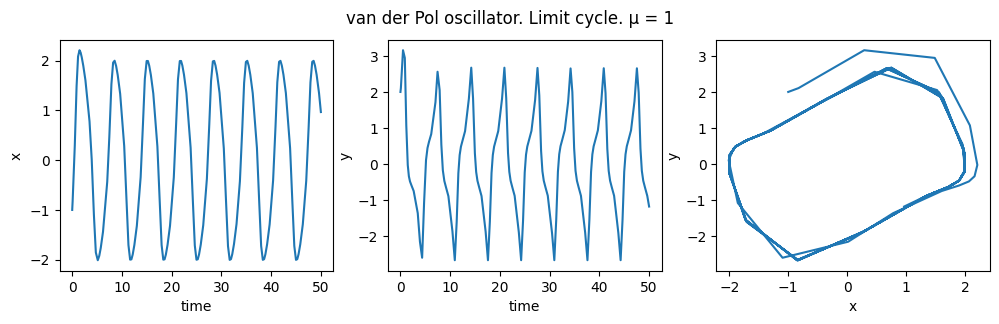

In [7]:
f,(ax, ax1, ax2) = plt.subplots(1,3, figsize=(12,3))

ax.plot(solution.t, solution.y[0, :], label='x')
ax.set_ylabel('x')
ax.set_xlabel('time')

ax1.plot(solution.t, solution.y[1, :], label='y')
ax1.set_ylabel('y')
ax1.set_xlabel('time')

ax2.plot(solution.y[0], solution.y[1])
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.suptitle(f'van der Pol oscillator. Limit cycle. µ = {params.mu}')

# Stable focus

In [8]:
state_initial = (-1, 2)

params_focus = ParamSet(mu=-0.5)

In [9]:
traj_focus = solve_ivp(vdp, [0, 30], state_initial, args=(params_focus,), max_step = 0.01)

## Show solution vs time

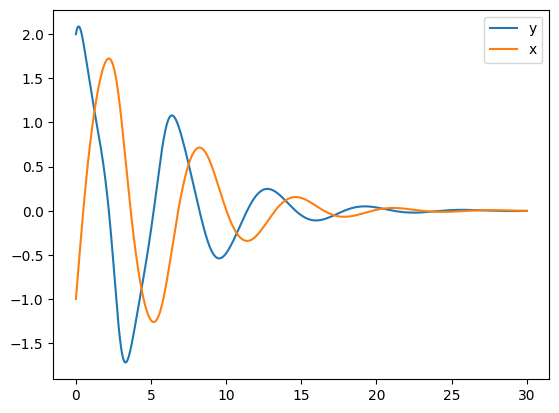

In [10]:
plt.plot(traj_focus.t, traj_focus.y[1,:], label='y')
plt.plot(traj_focus.t, traj_focus.y[0,:], label='x')
plt.legend()

## Show vector field with a phase trajectory - Stable focus (Fig. 1.3)

In [11]:
n = 24 # number of vectors we want to plot (along each dimension). Total number
# of vectors is n*n

X, Y = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3,n))

dx, dy = vdp(0, [X, Y], model_parameters=params_focus)

norm = np.linalg.norm([dx, dy], axis=0)

Text(0.5, 1.0, 'van der Pol oscillator. Stable focus. µ = -0.5')

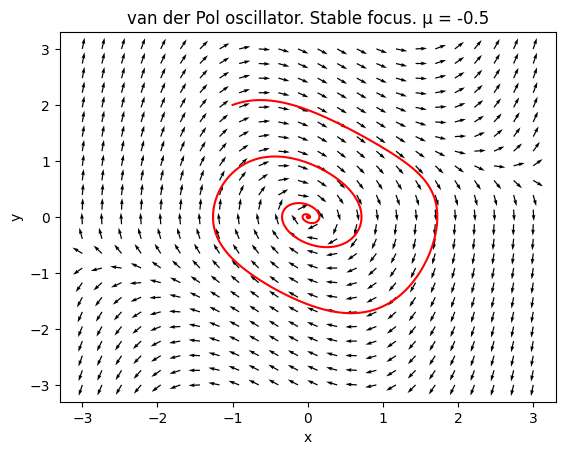

In [12]:
plt.figure()
plt.quiver(X, Y, dx/norm, dy/norm)
plt.plot(traj_focus.y[0], traj_focus.y[1], color='r')
plt.xlabel('x')
plt.ylabel('y')

plt.title(f'van der Pol oscillator. Stable focus. µ = {params_focus.mu}')

## Vector field with multiple phase trajectories starting from different initial condition - Stable focus (Fig. 1.4)

In [13]:
x0s = np.arange(-1, 0.1, 0.2)
y0 = state_initial[1]

trajectories = []

for x0 in x0s:

    xy_initial = (x0, y0)
    traj = solve_ivp(vdp, [0, 30], xy_initial, args=(params_focus,), max_step = 0.01)
    traj.xy_initial = xy_initial

    trajectories.append(traj)


#### Show trajectories

Text(0.5, 1.0, 'van der Pol oscillator. Stable focus. µ = -0.5, y(0) = 2')

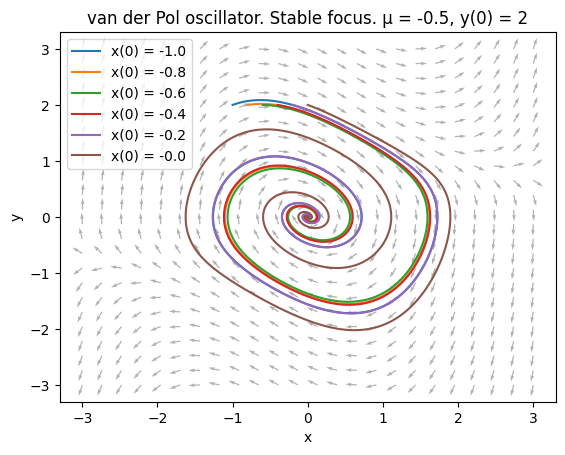

In [14]:
plt.figure()
plt.quiver(X, Y, dx/norm, dy/norm, alpha=0.3)

for x0, traj in zip(x0s, trajectories):
    plt.plot(*traj.y, label=f"x(0) = {np.round(x0, 1)}")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')

plt.title(f'van der Pol oscillator. Stable focus. µ = {params_focus.mu}, y(0) = {y0}')

# Stable node

## Vector field and phase trajectory (Fig. 1.5)

In [16]:
n = 25

X, Y = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3,n))

params_node = ParamSet(mu=-5)
dx,dy = vdp(0, [X, Y], model_parameters=params_node)
traj_node = solve_ivp(vdp, [0, 30], state_initial, args=(params_node,), max_step = 0.01)

norm = np.linalg.norm([dx, dy], axis=0)

/tmp/ipython-input-2487906176.py:2: RuntimeWarning: invalid value encountered in divide
  plt.quiver(X, Y, dx/norm, dy/norm)


Text(0.5, 1.0, 'van der Pol oscillator. Stable node. µ = -5')

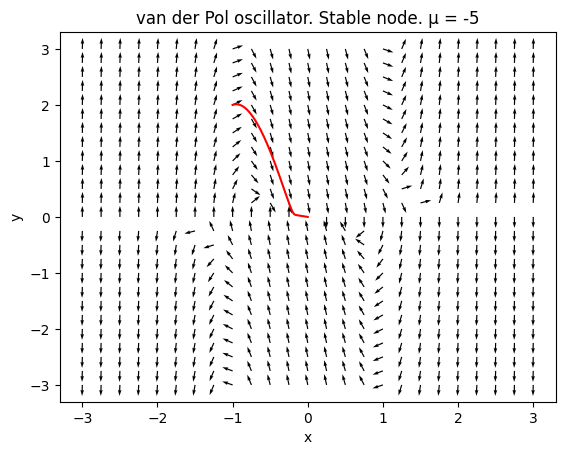

In [17]:
plt.figure()
plt.quiver(X, Y, dx/norm, dy/norm)

plt.plot(traj_node.y[0, :], traj_node.y[1, :], color='r')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'van der Pol oscillator. Stable node. µ = {params_node.mu}')

## Vector field with multiple phase trajectories starting from different initial condition - Stable node (Fig. 1.6)

In [18]:
x0s = np.arange(-1.4, 0.1, 0.2)
# y0 = state_initial[1]

trajectories = []

for x0 in x0s:

    xy_initial = (x0, y0)
    traj = solve_ivp(vdp, [0, 30], xy_initial, args=(params_node,), max_step = 0.01)
    traj.xy_initial = xy_initial

    trajectories.append(traj)


#### Show trajectories

/tmp/ipython-input-2712049618.py:2: RuntimeWarning: invalid value encountered in divide
  plt.quiver(X, Y, dx/norm, dy/norm, alpha=0.3)


Text(0.5, 1.0, 'van der Pol oscillator. Stable node. µ = -5, y(0) = 2')

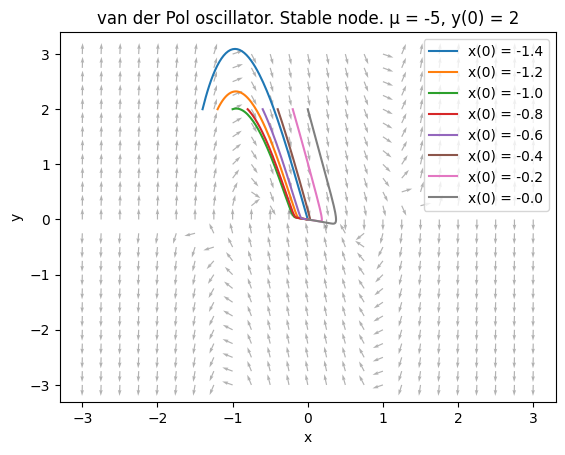

In [19]:
plt.figure()
plt.quiver(X, Y, dx/norm, dy/norm, alpha=0.3)

for x0, traj in zip(x0s, trajectories):
    plt.plot(*traj.y, label=f"x(0) = {np.round(x0, 1)}")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')

plt.title(f'van der Pol oscillator. Stable node. µ = {params_node.mu}, y(0) = {y0}')

# Limit cycle

## Multiple trajectories on the vector field

In [20]:
n = 25

X, Y = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3,n))

dx,dy = vdp(0, [X, Y], model_parameters=params)
# traj_node = solve_ivp(vdp, [0, 30], state_initial, args=(params,), max_step = 0.01)

norm = np.linalg.norm([dx, dy], axis=0)

In [21]:
states_initial = np.array([np.linspace(-1.4, 0.1, 5),
                           np.linspace(2, 0, 5)])

trajectories = []

for x0, y0 in states_initial.T:

    traj = solve_ivp(vdp, [0, 30], (x0, y0), args=(params,), max_step = 0.01)
    traj.xy_initial = xy_initial

    trajectories.append(traj)


#### Show trajectories

/tmp/ipython-input-3017751520.py:2: RuntimeWarning: invalid value encountered in divide
  plt.quiver(X, Y, dx/norm, dy/norm, alpha=0.3)


Text(0.5, 1.0, 'van der Pol oscillator. Limit cycle. µ = 1')

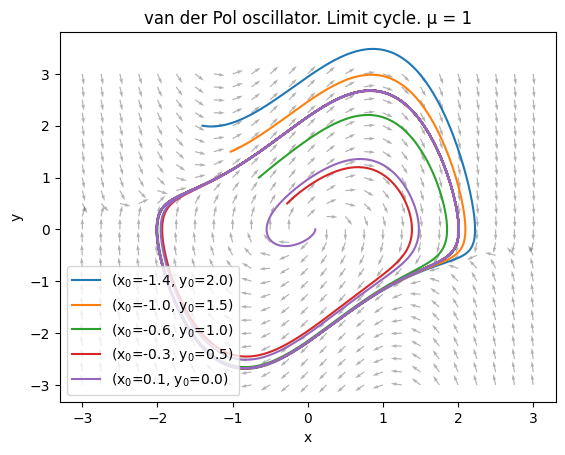

In [22]:
plt.figure()
plt.quiver(X, Y, dx/norm, dy/norm, alpha=0.3)

for (x0, y0), traj in zip(states_initial.T, trajectories):
    plt.plot(*traj.y, label=f"(x$_0$={np.round(x0, 1)}, y$_0$={np.round(y0, 1)})")
plt.legend(loc='lower left')
plt.xlabel('x')
plt.ylabel('y')

plt.title(f'van der Pol oscillator. Limit cycle. µ = {params.mu}')

# Chaos in van der Pol oscillator with external forcing (Fig. 1.9, modified)

We model the external force as a periodic function of time

### model:

$$
\begin{align}
\frac{\text{d}x}{\text{d}t} &= y\\
\frac{\text{d}y}{\text{d}t} &= \mu (1 - x^2) y -x + a * sin(w t)
\end{align}
$$

In [23]:
# def vdp_forced(t, state, mu=1, a=1, w=1):
#     x, y = state
#     return [y, mu*(1-x**2)*y - x + a*np.sin(w*t)]

## Our model function
def vdp_forced(t, state, model_parameters):

    x, y = state
    mp = model_parameters

    dxdt = y
    dydt = mp.mu * (1 - x**2) * y - x + mp.a*np.sin(mp.w*t)

    return dxdt, dydt


ParamSet_forced = namedtuple('params', 'mu a w')

In [24]:
state_initial = (-1, 2)
params_forced_chaos = ParamSet_forced(mu=8.53, a=1.2, w=2*np.pi/10)

In [26]:
solution = solve_ivp(vdp_forced, [0, 500],
                     state_initial,
                     args=(params_forced_chaos,),
                     max_step = 0.01)

### Visualize results

Show how state variables `x` and `y` change with time and the phase trajectory

Text(0.5, 0, 'x')

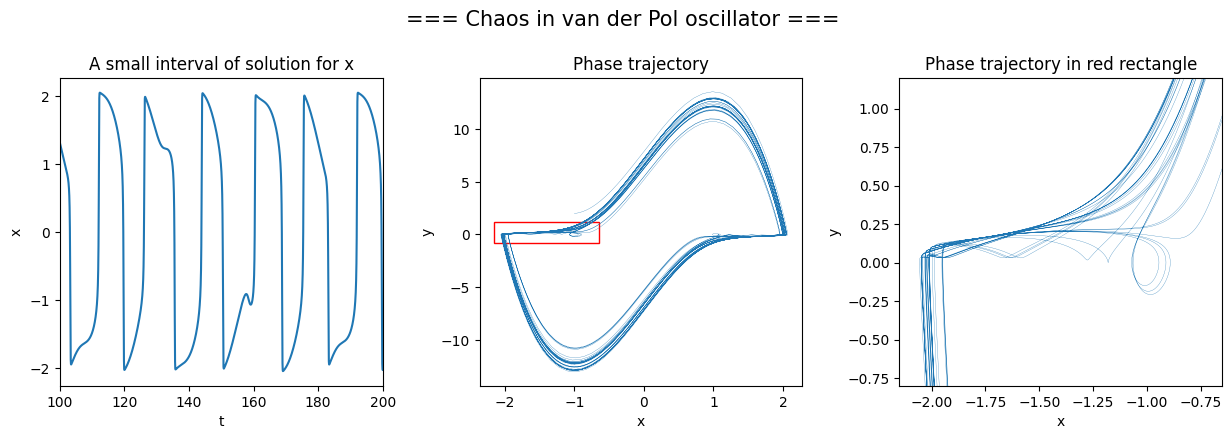

In [27]:
f,(ax, ax1, ax2) = plt.subplots(1,3, figsize=(15,4))
plt.subplots_adjust(wspace=0.3)

plt.suptitle('=== Chaos in van der Pol oscillator ===', fontsize=15, y=1.05)

ax.plot(solution.t, solution.y[0, :])
ax.set_ylabel('x')
ax.set_xlabel('t')
ax.set_xlim(100, 200)
ax.set_title('A small interval of solution for x')

ax1.plot(solution.y[0, :], solution.y[1, :], lw=0.2)
ax1.set_title('Phase trajectory')
ax1.set_ylabel('y')
ax1.set_xlabel('x')

xy0, w, h = (-2.15, -0.8), 1.5, 2
# xy0, w, h = (0.7, -0.8), 1.5, 2
ax1.add_patch(plt.Rectangle(xy0, w, h, fill=False, color='r'))


ax2.plot(solution.y[0, :], solution.y[1, :], lw=0.2)
ax2.set_title('Phase trajectory in red rectangle')
ax2.set_xlim(xy0[0], xy0[0]+w)
ax2.set_ylim(xy0[1], xy0[1]+h)
ax2.set_ylabel('y')
ax2.set_xlabel('x')
